## Imports

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import os
import sys
import matplotlib.pyplot as plt

#CHANGE AS NEEDED
sys.path.append('/home/patrick/ansermodelling')
os.chdir("/home/patrick/ansermodelling")


from models.FFNN_network import FFNN
from data.anser_dataset import AnserDataset
from models.train import train
from torch.utils.data import Subset


## Training with noise

In [2]:
### sigma = 0

In [3]:
def train_with_noise_plot(std):
    train_dataset = AnserDataset("data/dataset.npz", noise_std=std)
    test_dataset  = AnserDataset("data/dataset.npz", noise_std=0.0)
    
    n = len(train_dataset)
    n_train = int(0.8 * n)
    
    idx = np.random.permutation(n)
    train_idx, test_idx = idx[:n_train], idx[n_train:]
    
    
    train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=32, shuffle=True)
    test_loader  = DataLoader(Subset(test_dataset,  test_idx),  batch_size=32, shuffle=False)
    
    model = FFNN(input_dim=8, output_dim=5, hidden_dims=[64,256,64])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_losses, test_losses = train(model, train_loader, test_loader, optimizer, epochs=100, print_losses = True)

    fig, axes = plt.subplots(2,figsize=(10, 8))
    fig.suptitle(f'Noise std = {std}')
    axes[0].plot(train_losses)
    axes[0].set_title("train")
    axes[1].plot(test_losses)
    axes[1].set_title("test")
    plt.tight_layout()
    plt.show()

    


epoch 	 Training Loss 	 Test Loss 	 Mean pos error train 	 Mean Pos Error Test
1 	 0.6584 	  0.5027 	 0.1231 	 0.1037
2 	 0.4479 	  0.4103 	 0.0966 	 0.0973
3 	 0.3917 	  0.3781 	 0.0909 	 0.0883
4 	 0.3660 	  0.3532 	 0.0886 	 0.0843
5 	 0.3483 	  0.3370 	 0.0863 	 0.0850
6 	 0.3376 	  0.3344 	 0.0858 	 0.0842
7 	 0.3257 	  0.3251 	 0.0852 	 0.0850
8 	 0.3169 	  0.3141 	 0.0857 	 0.0843
9 	 0.3108 	  0.3073 	 0.0857 	 0.0830
10 	 0.3013 	  0.3123 	 0.0852 	 0.0848
11 	 0.2961 	  0.3001 	 0.0845 	 0.0849
12 	 0.2909 	  0.2972 	 0.0847 	 0.0854
13 	 0.2856 	  0.2901 	 0.0841 	 0.0842
14 	 0.2812 	  0.2865 	 0.0843 	 0.0844
15 	 0.2776 	  0.2845 	 0.0848 	 0.0844
16 	 0.2721 	  0.2822 	 0.0844 	 0.0855
17 	 0.2692 	  0.2830 	 0.0851 	 0.0866
18 	 0.2659 	  0.2858 	 0.0846 	 0.0823
19 	 0.2619 	  0.2782 	 0.0846 	 0.0855
20 	 0.2599 	  0.2936 	 0.0845 	 0.0852
21 	 0.2567 	  0.2818 	 0.0846 	 0.0841
22 	 0.2543 	  0.2684 	 0.0851 	 0.0816
23 	 0.2528 	  0.2732 	 0.0846 	 0.0854
24 	 0.250

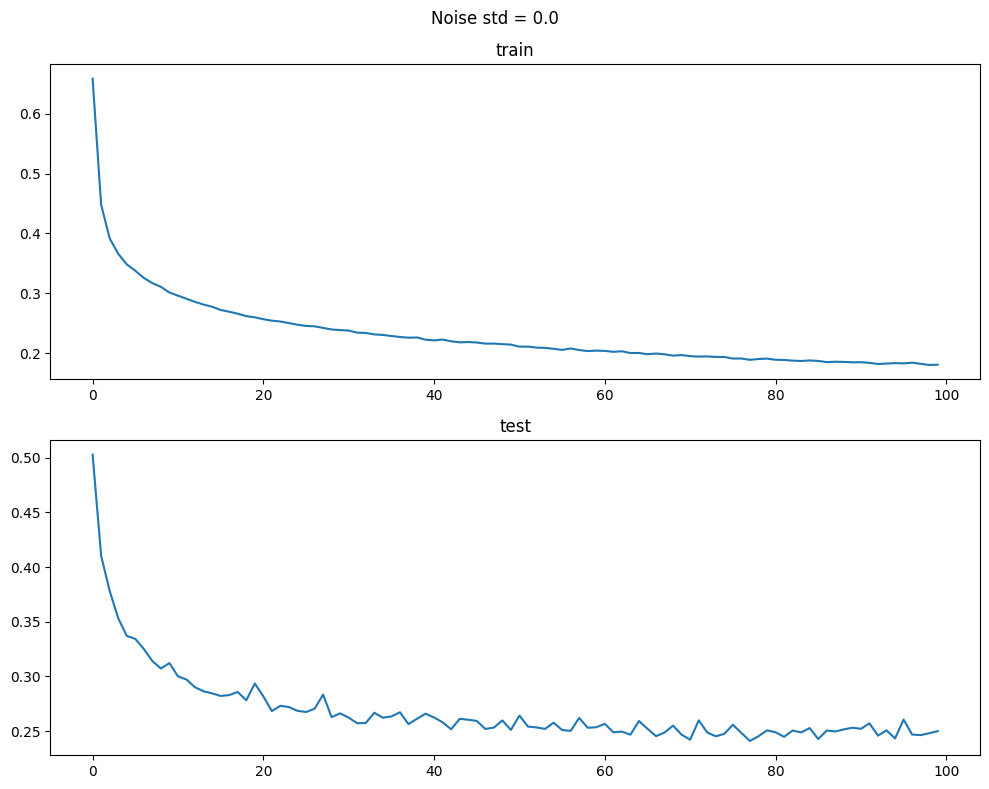

In [4]:
train_with_noise_plot(0.0)

epoch 	 Training Loss 	 Test Loss 	 Mean pos error train 	 Mean Pos Error Test
1 	 0.6610 	  0.4950 	 0.1204 	 0.1006
2 	 0.4575 	  0.4247 	 0.0946 	 0.0896
3 	 0.4048 	  0.3820 	 0.0931 	 0.0963
4 	 0.3781 	  0.3633 	 0.0953 	 0.0964
5 	 0.3622 	  0.3472 	 0.0972 	 0.0954
6 	 0.3502 	  0.3502 	 0.0974 	 0.0958
7 	 0.3406 	  0.3282 	 0.0975 	 0.0991
8 	 0.3321 	  0.3288 	 0.0971 	 0.0979
9 	 0.3252 	  0.3313 	 0.0966 	 0.0964
10 	 0.3188 	  0.3284 	 0.0968 	 0.0978
11 	 0.3146 	  0.3203 	 0.0970 	 0.0957
12 	 0.3102 	  0.3235 	 0.0975 	 0.0952
13 	 0.3031 	  0.3034 	 0.0965 	 0.0958
14 	 0.2993 	  0.2986 	 0.0971 	 0.0995
15 	 0.2964 	  0.2964 	 0.0978 	 0.0971
16 	 0.2951 	  0.3000 	 0.0978 	 0.0984
17 	 0.2902 	  0.2938 	 0.0979 	 0.0984
18 	 0.2866 	  0.2977 	 0.0981 	 0.0984
19 	 0.2833 	  0.2824 	 0.0986 	 0.0962
20 	 0.2830 	  0.2918 	 0.0987 	 0.0985
21 	 0.2810 	  0.2950 	 0.0986 	 0.0995
22 	 0.2789 	  0.2849 	 0.0995 	 0.0993
23 	 0.2776 	  0.2815 	 0.0985 	 0.0993
24 	 0.274

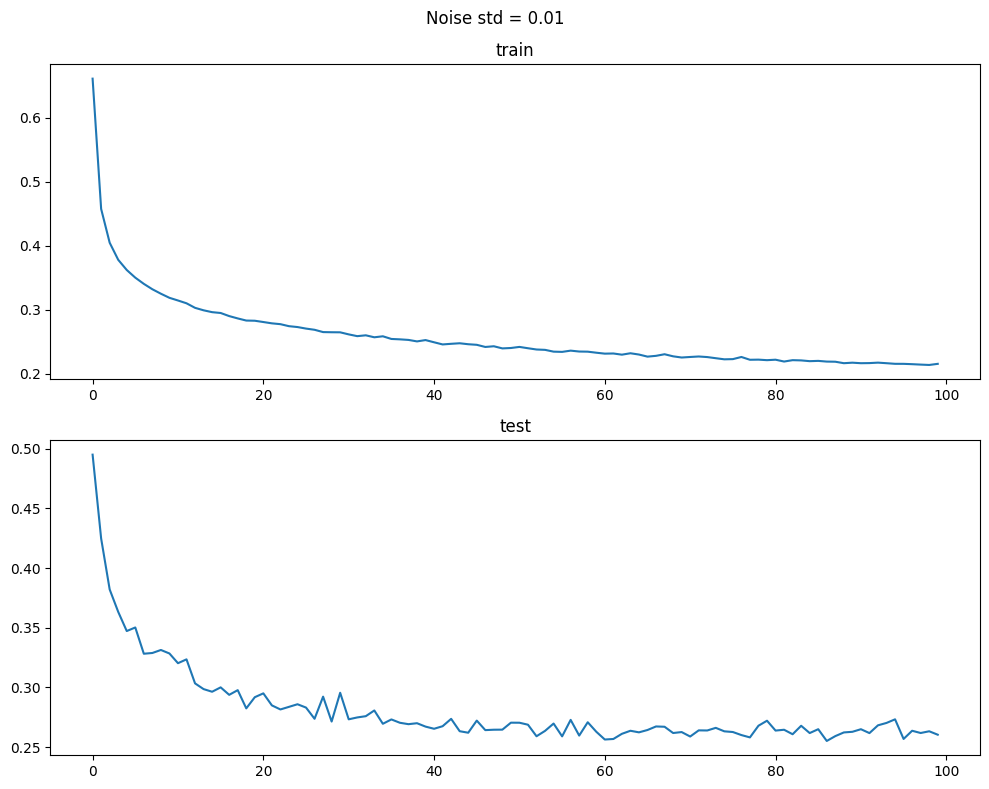

In [5]:
train_with_noise_plot(0.01)

In [6]:
'''
with old data
Epoch 95, train loss: 0.0063, test loss: 0.0068
Epoch 96, train loss: 0.0063, test loss: 0.0070
Epoch 97, train loss: 0.0062, test loss: 0.0068
Epoch 98, train loss: 0.0063, test loss: 0.0068
Epoch 99, train loss: 0.0063, test loss: 0.0070
'''

'\nwith old data\nEpoch 95, train loss: 0.0063, test loss: 0.0068\nEpoch 96, train loss: 0.0063, test loss: 0.0070\nEpoch 97, train loss: 0.0062, test loss: 0.0068\nEpoch 98, train loss: 0.0063, test loss: 0.0068\nEpoch 99, train loss: 0.0063, test loss: 0.0070\n'

epoch 	 Training Loss 	 Test Loss 	 Mean pos error train 	 Mean Pos Error Test
1 	 0.6851 	  0.5402 	 0.1236 	 0.1016
2 	 0.5380 	  0.4664 	 0.1030 	 0.0936
3 	 0.5058 	  0.4705 	 0.1017 	 0.0957
4 	 0.4894 	  0.4417 	 0.1011 	 0.0969
5 	 0.4771 	  0.4231 	 0.1007 	 0.0947
6 	 0.4703 	  0.4130 	 0.1007 	 0.0977
7 	 0.4660 	  0.4095 	 0.1005 	 0.0932
8 	 0.4625 	  0.4064 	 0.0989 	 0.0966
9 	 0.4582 	  0.3958 	 0.0993 	 0.0923
10 	 0.4583 	  0.3992 	 0.0986 	 0.0926
11 	 0.4521 	  0.3940 	 0.0998 	 0.0931
12 	 0.4496 	  0.3947 	 0.0997 	 0.0919
13 	 0.4479 	  0.4012 	 0.0990 	 0.0949
14 	 0.4471 	  0.4018 	 0.0996 	 0.0925
15 	 0.4436 	  0.3868 	 0.0997 	 0.0935
16 	 0.4448 	  0.3862 	 0.1002 	 0.0950
17 	 0.4429 	  0.3880 	 0.0990 	 0.0951
18 	 0.4418 	  0.3881 	 0.0994 	 0.0923
19 	 0.4405 	  0.3851 	 0.0982 	 0.0942
20 	 0.4400 	  0.3911 	 0.0996 	 0.0954
21 	 0.4393 	  0.3781 	 0.0994 	 0.0945
22 	 0.4385 	  0.3900 	 0.0988 	 0.0910
23 	 0.4396 	  0.3805 	 0.0977 	 0.0948
24 	 0.434

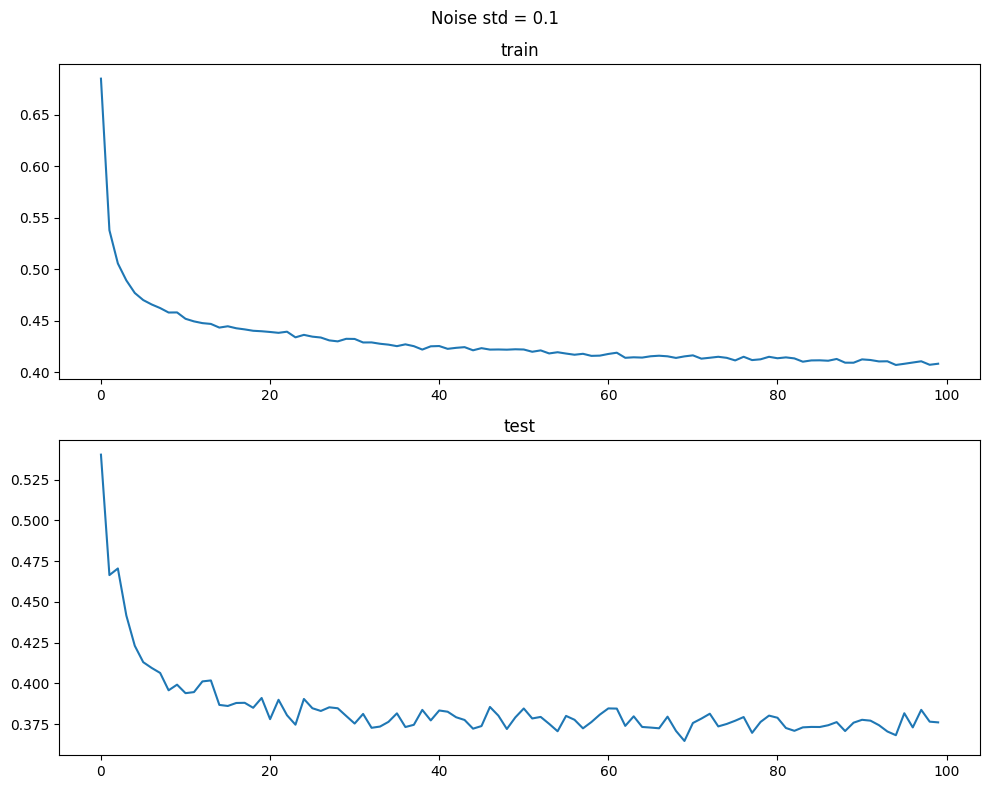

In [7]:
train_with_noise_plot(0.1)

epoch 	 Training Loss 	 Test Loss 	 Mean pos error train 	 Mean Pos Error Test
1 	 0.7906 	  0.7217 	 0.1445 	 0.1264
2 	 0.7418 	  0.7015 	 0.1369 	 0.1259
3 	 0.7365 	  0.6919 	 0.1350 	 0.1233
4 	 0.7317 	  0.6933 	 0.1342 	 0.1152
5 	 0.7309 	  0.6936 	 0.1318 	 0.1162
6 	 0.7278 	  0.6865 	 0.1313 	 0.1136
7 	 0.7259 	  0.6880 	 0.1302 	 0.1180
8 	 0.7231 	  0.6808 	 0.1305 	 0.1165
9 	 0.7237 	  0.6887 	 0.1304 	 0.1147
10 	 0.7256 	  0.6880 	 0.1306 	 0.1172
11 	 0.7236 	  0.7032 	 0.1307 	 0.1261
12 	 0.7241 	  0.6864 	 0.1304 	 0.1239
13 	 0.7216 	  0.6856 	 0.1305 	 0.1199
14 	 0.7207 	  0.6834 	 0.1306 	 0.1178
15 	 0.7234 	  0.6840 	 0.1309 	 0.1262
16 	 0.7208 	  0.6802 	 0.1303 	 0.1231
17 	 0.7213 	  0.6824 	 0.1308 	 0.1242
18 	 0.7202 	  0.6827 	 0.1310 	 0.1181
19 	 0.7212 	  0.6871 	 0.1299 	 0.1202
20 	 0.7206 	  0.6877 	 0.1302 	 0.1164
21 	 0.7201 	  0.6851 	 0.1304 	 0.1225
22 	 0.7196 	  0.6827 	 0.1305 	 0.1148
23 	 0.7209 	  0.6852 	 0.1300 	 0.1165
24 	 0.719

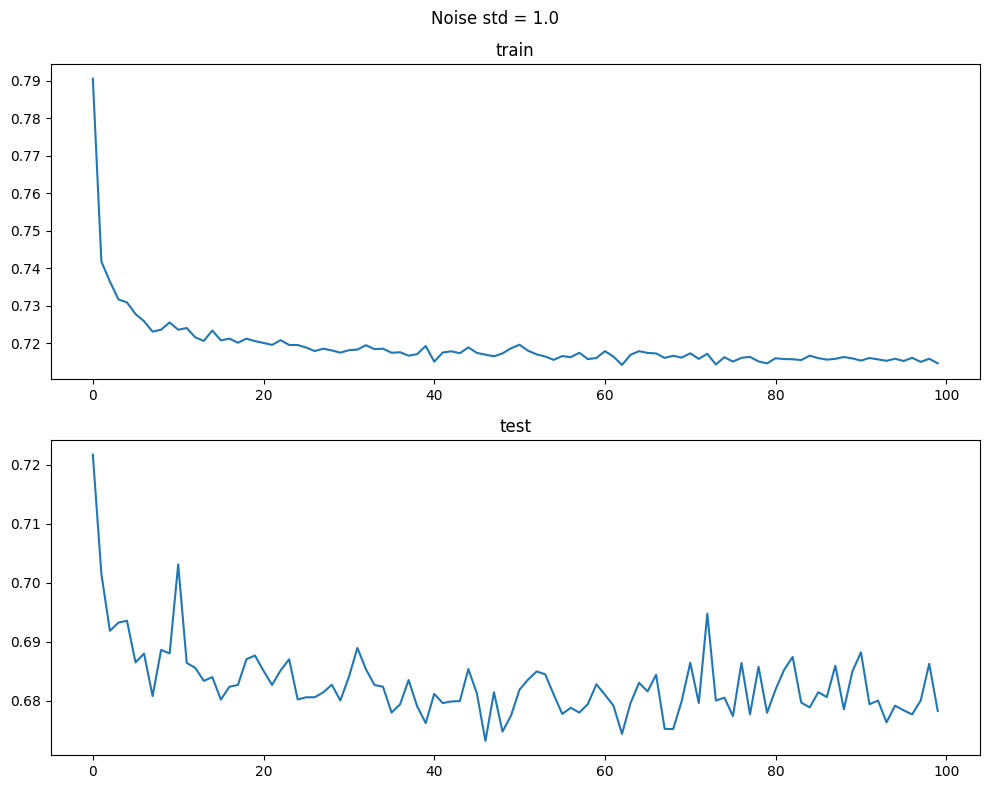

In [8]:
train_with_noise_plot(1.0)

epoch 	 Training Loss 	 Test Loss 	 Mean pos error train 	 Mean Pos Error Test
1 	 0.8620 	  0.8125 	 0.1711 	 0.1600
2 	 0.8301 	  0.8180 	 0.1671 	 0.1598
3 	 0.8288 	  0.8083 	 0.1670 	 0.1598
4 	 0.8282 	  0.8181 	 0.1668 	 0.1607
5 	 0.8285 	  0.8172 	 0.1670 	 0.1659
6 	 0.8285 	  0.8101 	 0.1673 	 0.1688
7 	 0.8281 	  0.8116 	 0.1673 	 0.1616
8 	 0.8283 	  0.8118 	 0.1675 	 0.1663
9 	 0.8284 	  0.8105 	 0.1674 	 0.1599
10 	 0.8286 	  0.8116 	 0.1673 	 0.1658
11 	 0.8282 	  0.8081 	 0.1672 	 0.1630
12 	 0.8276 	  0.8154 	 0.1669 	 0.1622
13 	 0.8286 	  0.8119 	 0.1668 	 0.1634
14 	 0.8284 	  0.8199 	 0.1669 	 0.1627
15 	 0.8281 	  0.8104 	 0.1669 	 0.1634
16 	 0.8278 	  0.8081 	 0.1673 	 0.1606
17 	 0.8280 	  0.8179 	 0.1668 	 0.1624
18 	 0.8286 	  0.8136 	 0.1677 	 0.1637
19 	 0.8279 	  0.8148 	 0.1671 	 0.1620
20 	 0.8281 	  0.8135 	 0.1671 	 0.1626
21 	 0.8278 	  0.8065 	 0.1668 	 0.1622
22 	 0.8279 	  0.8106 	 0.1669 	 0.1657
23 	 0.8281 	  0.8129 	 0.1669 	 0.1616
24 	 0.828

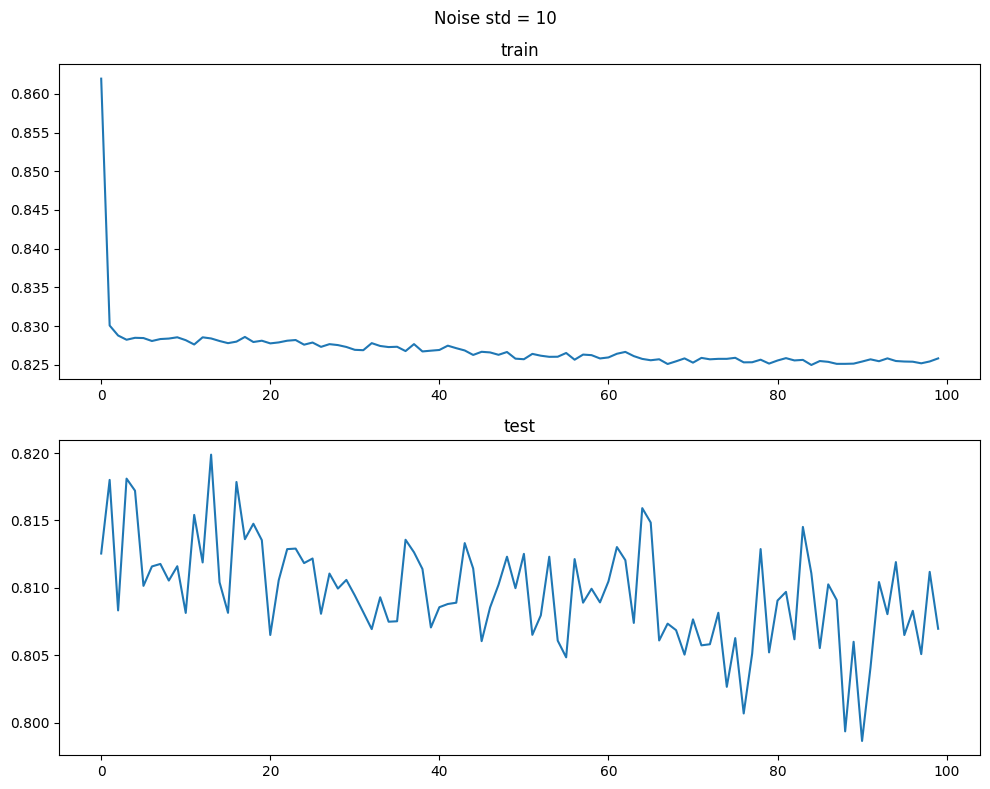

In [9]:
train_with_noise_plot(10)